# NB07 — Interpretabilidad KAN head sobre embeddings (Rama A)

**Objetivo:** Analizar qué aprende la KAN cuando se entrena sobre features
ya abstraidas por ResNet-18 congelado.

**Prerequisito:** Ejecutar `05_kan_head_train.ipynb` primero.
Carga `kan_head_embeddings.pt` y `kan_head_norm_stats.pt`.

**Análisis incluido:**
1. Evaluación cuantitativa (AUC, recall, F1)
2. Importancia de aristas (Sproud) — ¿cuántas de las 512 dimensiones importan?
3. Plot de splines top-K por importancia
4. Comparativa maligno vs benigno — ¿difieren las activaciones?
5. `auto_symbolic()` — ¿qué funciones matemáticas se aproximan a las splines?

**Contraparte:** Ver `08_end2end_interpretability.ipynb` (Rama B) para comparar.

In [1]:
# --- Setup e imports ---
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import importlib.util
if not importlib.util.find_spec('kan'):
    raise RuntimeError("PyKAN no instalado. Ejecuta: pip install pykan")

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from kan import KAN

import notebook_utils as nu
import kan_plot_utils as kpu
import paths

# Configuración
SEED        = 42
SPROUD_TOP_K = 16   # Top-K aristas a analizar por importancia
PLOT_LAYER  = 0     # Capa del KAN a visualizar (0 = primera)
SYM_TOP_K   = 8    # Top-K aristas para auto_symbolic
SYM_LIB     = ['x', 'x^2', 'x^3', 'exp', 'log', 'sin', 'abs', 'sqrt']  # librería de funciones

nu.seed_everything(SEED)
DEVICE = nu.pick_device()
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
# --- Rutas y verificación ---
TUNED_BACKBONE  = ROOT / 'reports/models/resnet18_tuned_best.pt'
KAN_HEAD_PATH   = ROOT / 'reports/models/kan_head_embeddings.pt'
NORM_STATS_PATH = ROOT / 'reports/models/kan_head_norm_stats.pt'

for p in [TUNED_BACKBONE, KAN_HEAD_PATH, NORM_STATS_PATH]:
    assert p.exists(), f'Archivo no encontrado: {p}\nEjecuta primero 05_kan_head_train.ipynb'
    print(f'  OK  {p.name}')

  OK  resnet18_tuned_best.pt
  OK  kan_head_embeddings.pt
  OK  kan_head_norm_stats.pt


In [3]:
# --- Carga de datos y embeddings ---
tr_df, val_df, test_df = nu.load_manifest_splits(
    paths.MANIFEST_TRAIN, paths.MANIFEST_TEST, seed=SEED, test_size=0.2
)
tfm = nu.default_transforms(img_size=224, augment=False)

loaders = {
    'train': DataLoader(nu.MammographyDataset(tr_df,   tfm), batch_size=32, shuffle=False, num_workers=0),
    'val':   DataLoader(nu.MammographyDataset(val_df,  tfm), batch_size=32, shuffle=False, num_workers=0),
    'test':  DataLoader(nu.MammographyDataset(test_df, tfm), batch_size=32, shuffle=False, num_workers=0),
}

# Cargar estadísticas de normalización guardadas en NB05 (reproducibilidad exacta)
norm = torch.load(NORM_STATS_PATH, map_location='cpu')
mu, sigma = norm['mu'], norm['sigma']

backbone = nu.build_resnet18_backbone(TUNED_BACKBONE, DEVICE)
embeddings, _ = nu.extract_and_normalize_embeddings(
    backbone, loaders, DEVICE, norm_stats=(mu, sigma)
)

(Xtr, ytr) = embeddings['train']
(Xva, yva) = embeddings['val']
(Xte, yte) = embeddings['test']
print(f'Embeddings — train: {Xtr.shape} | val: {Xva.shape} | test: {Xte.shape}')

Embeddings — train: torch.Size([2315, 512]) | val: torch.Size([549, 512]) | test: torch.Size([422, 512])


In [4]:
# --- Cargar KAN head ---
kan = KAN(width=[512, 32, 2], grid=5, k=3, auto_save=False, seed=SEED).to(DEVICE)
kan.load_state_dict(torch.load(KAN_HEAD_PATH, map_location=DEVICE))
kan.eval()
print('KAN head cargado OK')

KAN head cargado OK


In [5]:
# --- 1. Evaluación cuantitativa ---
Xte_d, yte_d = Xte.to(DEVICE), yte.to(DEVICE)

with torch.no_grad():
    prob_te = torch.softmax(kan(Xte_d), dim=1)[:, 1].cpu().numpy()

thr = nu.choose_threshold_by_recall(yte.numpy(), prob_te, target_recall=0.80)
pred = (prob_te >= thr).astype(int)

metrics = nu.safe_binary_metrics(yte.numpy(), pred, prob_te)
print(f'Umbral por recall=0.80: {thr:.3f}')
for k, v in metrics.items():
    print(f'  {k:25s}: {v:.4f}')

Umbral por recall=0.80: 0.450
  acc                      : 0.6374
  recall_malignant         : 0.8103
  precision_malignant      : 0.5402
  f1_malignant             : 0.6483
  auc                      : 0.6932


In [6]:
# --- 2. Cachear activaciones (API PyKAN >= 0.2.x) ---
# Usamos el conjunto de validación completo para tener una muestra representativa
Xva_d = Xva.to(DEVICE)
with torch.no_grad():
    _ = kan(Xva_d)
kan.get_act(Xva_d)

print(f'Activaciones cacheadas:')
print(f'  acts:            {[list(a.shape) for a in kan.acts]}')
print(f'  spline_postacts: {[list(s.shape) for s in kan.spline_postacts]}')

Activaciones cacheadas:
  acts:            [[549, 512], [549, 32], [549, 2]]
  spline_postacts: [[549, 32, 512], [549, 2, 32]]


In [7]:
# --- 3. Tabla de importancia de aristas (Sproud) ---
import pandas as pd

sp = kan.spline_postacts[PLOT_LAYER]  # [N, out, in]
imp = sp.abs().mean(dim=0)            # [out_dim, in_dim]
out_dim, in_dim = imp.shape
total_edges = out_dim * in_dim

rows = []
for o in range(out_dim):
    for i in range(in_dim):
        rows.append({'out': o, 'in': i, 'importance': imp[o, i].item()})

sproud_df = pd.DataFrame(rows).sort_values('importance', ascending=False).reset_index(drop=True)
sproud_df['rank'] = sproud_df.index + 1
sproud_df['cumulative_importance'] = sproud_df['importance'].cumsum() / sproud_df['importance'].sum()

print(f'Total aristas: {total_edges} ({in_dim} entradas × {out_dim} salidas)')
print(f'\nTop-{SPROUD_TOP_K} aristas más importantes:')
display(sproud_df.head(SPROUD_TOP_K))

# ¿Cuántas aristas acumulan el 80% de la importancia?
n80 = (sproud_df['cumulative_importance'] <= 0.80).sum() + 1
print(f'\nAristas que acumulan el 80% de la importancia: {n80}/{total_edges} ({100*n80/total_edges:.1f}%)')

Total aristas: 16384 (512 entradas × 32 salidas)

Top-16 aristas más importantes:


,out,in,importance,rank,cumulative_importance
0,18,72,0.030006,1,0.000185
1,2,83,0.028185,2,0.000360
2,4,3,0.028159,3,0.000534
3,3,223,0.027508,4,0.000704
4,16,83,0.027399,5,0.000873
5,14,3,0.027386,6,0.001042
6,18,403,0.027336,7,0.001211
7,20,207,0.027104,8,0.001379
8,29,367,0.026965,9,0.001546
9,22,403,0.026807,10,0.001711



Aristas que acumulan el 80% de la importancia: 8920/16384 (54.4%)


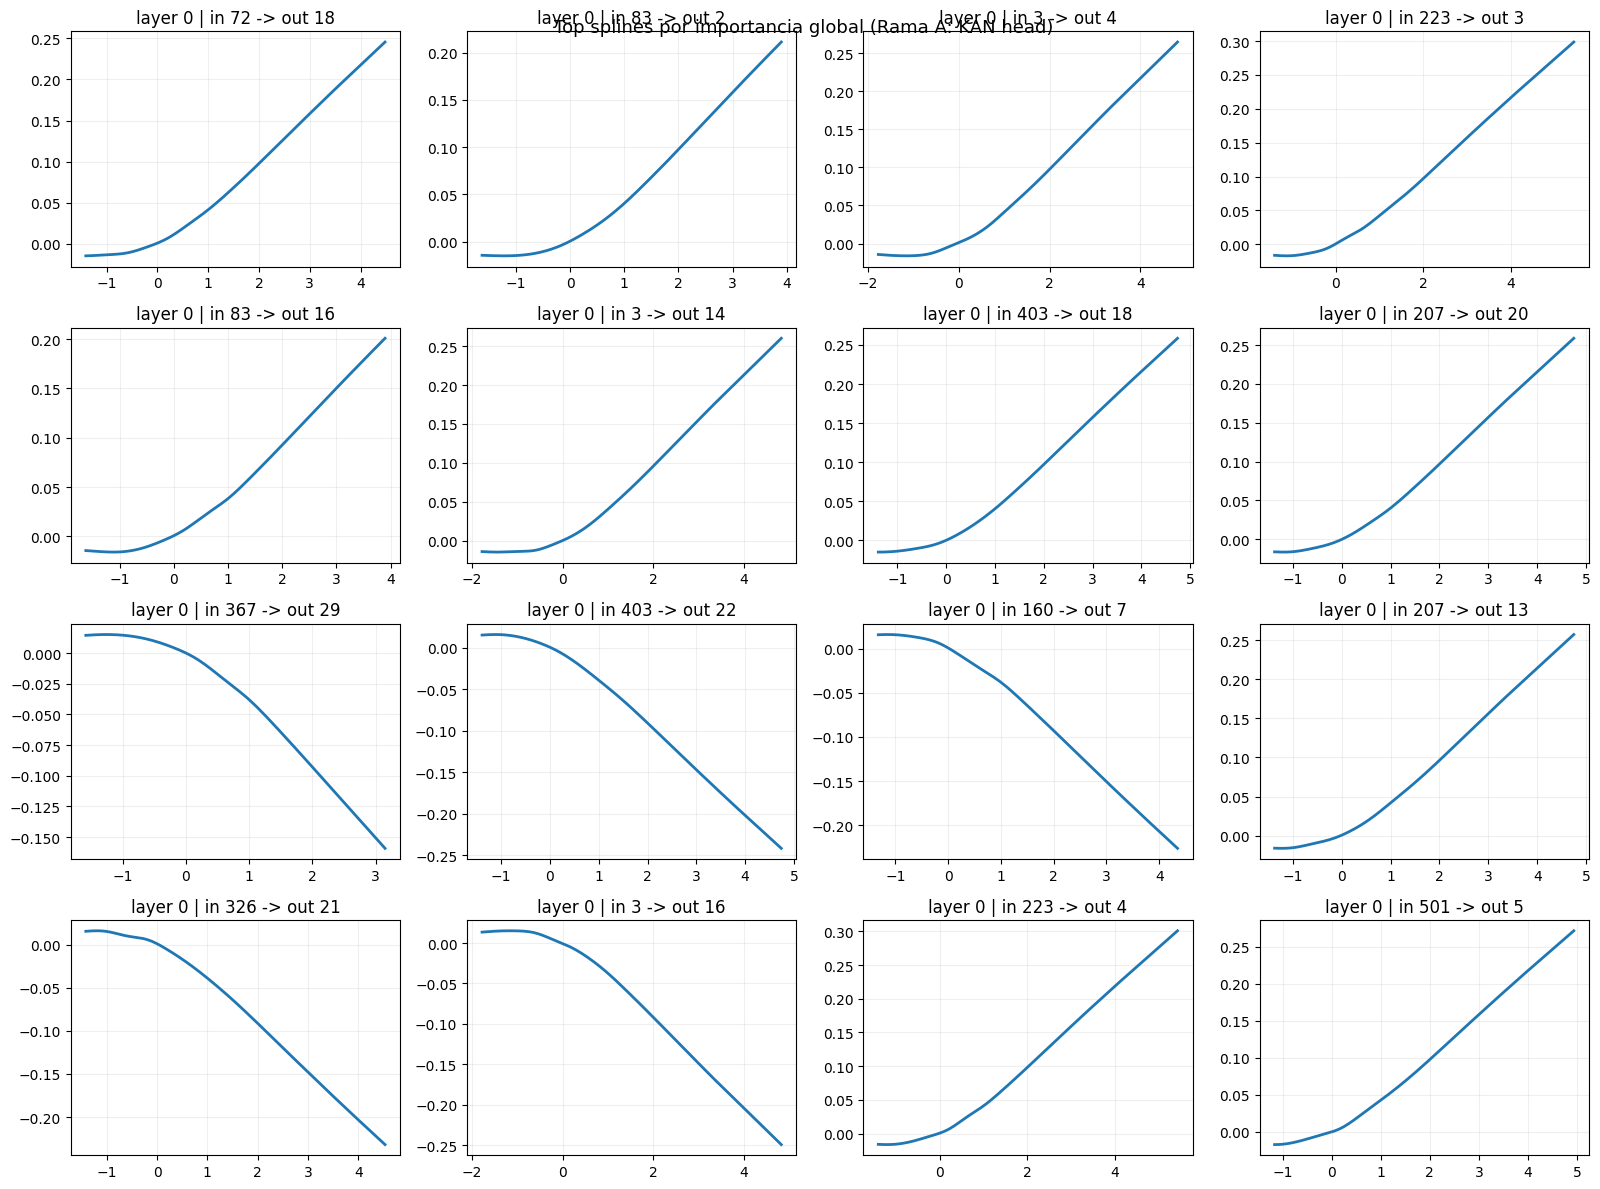

Pares (in→out): [(72, 18), (83, 2), (3, 4), (223, 3), (83, 16), (3, 14), (403, 18), (207, 20), (367, 29), (403, 22), (160, 7), (207, 13), (326, 21), (3, 16), (223, 4), (501, 5)]


In [8]:
# --- 4. Plot de splines top-K globales ---
fig, pairs = kpu.plot_kan_edges_light(
    kan, layer=PLOT_LAYER, top_k=SPROUD_TOP_K, cols=4
)
fig.suptitle('Top splines por importancia global (Rama A: KAN head)', fontsize=13)
plt.show()
print('Pares (in→out):', pairs)

In [9]:
# --- 5. Comparativa maligno vs benigno ---
Xtr_d = Xtr.to(DEVICE)

idx0 = (ytr == 0).nonzero(as_tuple=True)[0]
idx1 = (ytr == 1).nonzero(as_tuple=True)[0]

with torch.no_grad():
    _ = kan(Xtr_d[idx0]); kan.get_act(Xtr_d[idx0])
    imp0 = kan.spline_postacts[PLOT_LAYER].abs().mean(dim=0)   # benigno

    _ = kan(Xtr_d[idx1]); kan.get_act(Xtr_d[idx1])
    imp1 = kan.spline_postacts[PLOT_LAYER].abs().mean(dim=0)   # maligno

diff = (imp1 - imp0).flatten()
top_mal = torch.argsort(diff, descending=True)[:8]   # más activos en malignos
top_ben = torch.argsort(diff)[:8]                    # más activos en benignos

def flat_to_edge(idx, out_d, in_d):
    return int(idx // in_d), int(idx % in_d)

mal_edges = [flat_to_edge(i, out_dim, in_dim) for i in top_mal]
ben_edges = [flat_to_edge(i, out_dim, in_dim) for i in top_ben]

print('Splines más diferenciadores en MALIGNO:', mal_edges)
print('Splines más diferenciadores en BENIGNO:', ben_edges)

Splines más diferenciadores en MALIGNO: [(10, 488), (5, 488), (22, 490), (18, 488), (0, 274), (4, 510), (0, 478), (8, 478)]
Splines más diferenciadores en BENIGNO: [(26, 48), (10, 235), (8, 62), (20, 275), (22, 33), (24, 94), (22, 94), (30, 406)]


In [10]:
# --- 6. Regresión simbólica sobre las top-K aristas más importantes ---
# API PyKAN 0.2.8: suggest_symbolic(l, i, j, lib=[...], topk=5, verbose=False)
# Retorna: (fn_name: str, fn_internal: tuple, r2_score: float, complexity: int)

Xtr_d = Xtr.to(DEVICE)
with torch.no_grad():
    _ = kan(Xtr_d)
kan.get_act(Xtr_d)

if hasattr(kan, 'auto_save'):
    kan.auto_save = False
if hasattr(kan, 'unfix_symbolic_all'):
    kan.unfix_symbolic_all()

print(f'Regresion simbolica sobre top-{SYM_TOP_K} aristas (capa {PLOT_LAYER})')
print(f'Libreria: {SYM_LIB}')
print()

# Tomar las top aristas del dataframe Sproud
top_edges = sproud_df.head(SYM_TOP_K)[['in', 'out']].values.tolist()

results = []
for in_idx, out_idx in top_edges:
    in_idx, out_idx = int(in_idx), int(out_idx)
    imp = float(sproud_df[
        (sproud_df['in'] == in_idx) & (sproud_df['out'] == out_idx)
    ]['importance'].values[0])

    if hasattr(kan, 'suggest_symbolic'):
        try:
            # result[0]=fn_name, result[1]=fn_lambdas_internal,
            # result[2]=r2_score, result[3]=complexity
            result = kan.suggest_symbolic(
                PLOT_LAYER, in_idx, out_idx,
                lib=SYM_LIB, topk=5, verbose=False
            )
            fn_name   = result[0]            # str
            r2_score  = float(result[2])     # float64 -> float
            complexity = int(result[3])      # int32 -> int

            results.append({
                'layer': PLOT_LAYER,
                'in': in_idx, 'out': out_idx,
                'importance': round(imp, 6),
                'best_fn': fn_name,
                'R2': round(r2_score, 4),
                'complexity': complexity,
            })
            print(f'  (in={in_idx:3d} out={out_idx:2d})  {fn_name:10s}  R2={r2_score:.4f}  complexity={complexity}  imp={imp:.5f}')

        except Exception as e:
            results.append({'layer': PLOT_LAYER, 'in': in_idx, 'out': out_idx,
                            'importance': imp, 'best_fn': 'ERROR', 'R2': float('nan'), 'complexity': -1})
            print(f'  (in={in_idx:3d} out={out_idx:2d})  ERROR: {e}')
    else:
        print('suggest_symbolic no disponible en esta version de PyKAN')
        break

import pandas as pd
sym_df = pd.DataFrame(results)
print()
print('=== Tabla de regresion simbolica (top aristas) ===')
print(sym_df.to_string(index=False))

# Conteo de funciones identificadas
from collections import Counter
fn_counts = Counter(r['best_fn'] for r in results if r['best_fn'] != 'ERROR')
print()
print('Funciones mas frecuentes:', dict(fn_counts.most_common()))


Regresion simbolica sobre top-8 aristas (capa 0)
Libreria: ['x', 'x^2', 'x^3', 'exp', 'log', 'sin', 'abs', 'sqrt']

  (in= 72 out=18)  sin         R2=0.9996  complexity=2  imp=0.03001


  (in= 83 out= 2)  sin         R2=0.9998  complexity=2  imp=0.02818
  (in=  3 out= 4)  sin         R2=0.9995  complexity=2  imp=0.02816


  (in=223 out= 3)  sin         R2=0.9996  complexity=2  imp=0.02751
  (in= 83 out=16)  sin         R2=0.9999  complexity=2  imp=0.02740


  (in=  3 out=14)  sin         R2=0.9994  complexity=2  imp=0.02739
  (in=403 out=18)  sin         R2=0.9994  complexity=2  imp=0.02734


  (in=207 out=20)  sin         R2=0.9998  complexity=2  imp=0.02710

=== Tabla de regresion simbolica (top aristas) ===
 layer  in  out  importance best_fn     R2  complexity
     0  72   18    0.030006     sin 0.9996           2
     0  83    2    0.028185     sin 0.9998           2
     0   3    4    0.028159     sin 0.9995           2
     0 223    3    0.027508     sin 0.9996           2
     0  83   16    0.027399     sin 0.9999           2
     0   3   14    0.027386     sin 0.9994           2
     0 403   18    0.027336     sin 0.9994           2
     0 207   20    0.027104     sin 0.9998           2

Funciones mas frecuentes: {'sin': 8}


## Preguntas abiertas para la tesis

- ¿Cuántas de las 512 dimensiones del embedding son relevantes para la KAN?
  *(ver tabla Sproud: n80 = aristas que concentran el 80% de importancia)*
- ¿Las funciones identificadas por `auto_symbolic` tienen interpretación geométrica
  en términos de las features de ResNet-18?
- Comparar con `08_end2end_interpretability.ipynb`: ¿difieren las funciones cuando
  el backbone también se adapta?
- ¿Son estables los resultados bajo diferentes seeds?